# Random Forest

## Chuẩn bị dữ liệu

In [1]:
import numpy as np 
from collections import Counter
from sklearn.tree import DecisionTreeClassifier as DecisionTree

data = np.load("processed_data.npz")
#Flatten ảnh bằng cách reshape vì RandomForest không xử lý ảnh 2D
X_train = data["x_train"].reshape(50000,-1)
Y_train = data["y_train"]
X_val = data["x_val"].reshape(10000,-1)
Y_val = data["y_val"]
X_test = data["x_test"].reshape(10000,-1)
Y_test = data["y_test"]


## Khởi tạo class Random Forest

In [2]:
from decision_tree import DecisionTreeClassifier

In [3]:
class RandomForest:
    def __init__(self, n_estimators = 100, max_depth = None, min_samples_split = 2, max_features='sqrt', random_state=None):
        self.n_estimators = n_estimators 
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees=[]
        self.random_state = random_state
        self.feature_importances_ = None
        """ 
        n_estimators : Số lượng cây
        max_depth : Độ sâu tối đa của mỗi cây
        min_samples_split : Số samples tối thiểu để split node
        max_features : Số features để xem xét khi tìm best split
            - 'sqrt': sqrt(n_features)
            - 'log2': log2(n_features)
            - int: số cụ thể
        random_state : cho reproducibility
        """
        
    def _bootstrap_sample(self,x,y): #Tạo các tập mẫu ngẫu nhiên
        n_samples= x.shape[0]
        indices = np.random.choice(n_samples, size = n_samples, replace = True)
        return x[indices], y[indices]

    def fit (self, x, y): 
        if self.random_state is not None:
            np.random.seed(self.random_state)

        self.n_features_ = x.shape[1]
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.feature_importances_ = np.zeros(self.n_features_)
        self.trees=[]
        for i in range (self.n_estimators):
            x_sample, y_sample  = self._bootstrap_sample(x,y)
            # tree = DecisionTree(
            #     max_depth = self.max_depth,
            #     min_samples_split = self.min_samples_split,
            #     max_features = self._get_max_features()
            # )
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth, 
                min_samples_split=self.min_samples_split, 
                max_features = self._get_max_features()
            )
            tree.fit(x_sample,y_sample)
            self.trees.append(tree)
            print(f"Trained tree {i+1}/{self.n_estimators}")
            # cập nhật feature importances
            if hasattr(tree, 'feature_importances_'):
                self.feature_importances_ += tree.feature_importances_

        # Normalize feature importances
        self.feature_importances_ /= self.n_estimators
        return self

    def _get_max_features(self):
        # tính số features để xét tại mỗi lần split
        if self.max_features == 'sqrt':
            return int(np.sqrt(self.n_features_))
        elif self.max_features == 'log2':
            return int(np.log2(self.n_features_))
        elif isinstance(self.max_features, int):
            return self.max_features 
        else: 
            return self.n_features_

    def get_feature_importance(self):
        return self.feature_importances_

    def predict(self,x):
        predictions = np.array([tree.predict(x) for tree in self.trees])

        y_pred = []
        for i in range (x.shape[0]):
            votes = predictions[:,i]
            y_pred.append(self._majority_vote(votes))
        return np.array(y_pred)

    def _majority_vote(self, votes):
        #Tìm label có số vote nhiều nhất
        counter = Counter(votes)
        return counter.most_common(1)[0][0]

In [4]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_custom(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1
    return cm

## Test Random Forest vừa được khởi tạo

In [5]:
# Lấy tập mẫu nhỏ để test Random Forest
X_train_small = X_train[:2000]
Y_train_small = Y_train[:2000]

X_val_small = X_val[:500]
Y_val_small = Y_val[:500]


In [6]:
#Test nhanh Random Forest
rf_test = RandomForest(
    n_estimators=10,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_test.fit(X_train_small, Y_train_small)

y_pred = rf_test.predict(X_val_small)
acc = np.mean(y_pred == Y_val_small)

print("Quick test accuracy:", acc)
print("Kết luận: Random Forest hoạt động chính xác.")

Training completed in 0.67 seconds
Trained tree 1/10
Training completed in 0.62 seconds
Trained tree 2/10
Training completed in 0.65 seconds
Trained tree 3/10
Training completed in 0.66 seconds
Trained tree 4/10
Training completed in 0.69 seconds
Trained tree 5/10
Training completed in 0.66 seconds
Trained tree 6/10
Training completed in 0.63 seconds
Trained tree 7/10
Training completed in 0.68 seconds
Trained tree 8/10
Training completed in 0.65 seconds
Trained tree 9/10
Training completed in 0.67 seconds
Trained tree 10/10
Quick test accuracy: 0.824
Kết luận: Random Forest hoạt động chính xác.


### Tìm max_depth và min_samples_split tối ưu

In [7]:
depth_list = [5, 10, 15, 20]
min_samples_list = [2, 5, 10, 20]

results = []

for depth in depth_list:
    for min_samples in min_samples_list:
        rf = RandomForest(
            n_estimators=20,
            max_depth=depth,
            min_samples_split=min_samples,
            random_state=42
        )
        rf.fit(X_train_small, Y_train_small)
        acc = accuracy_score(Y_val, rf.predict(X_val))
        results.append((depth, min_samples, acc))
        print(f"depth={depth}, min_samples={min_samples} → val acc={acc:.4f}")


Training completed in 0.31 seconds
Trained tree 1/20
Training completed in 0.29 seconds
Trained tree 2/20
Training completed in 0.28 seconds
Trained tree 3/20
Training completed in 0.28 seconds
Trained tree 4/20
Training completed in 0.28 seconds
Trained tree 5/20
Training completed in 0.26 seconds
Trained tree 6/20
Training completed in 0.27 seconds
Trained tree 7/20
Training completed in 0.26 seconds
Trained tree 8/20
Training completed in 0.26 seconds
Trained tree 9/20
Training completed in 0.30 seconds
Trained tree 10/20
Training completed in 0.29 seconds
Trained tree 11/20
Training completed in 0.27 seconds
Trained tree 12/20
Training completed in 0.28 seconds
Trained tree 13/20
Training completed in 0.28 seconds
Trained tree 14/20
Training completed in 0.30 seconds
Trained tree 15/20
Training completed in 0.28 seconds
Trained tree 16/20
Training completed in 0.25 seconds
Trained tree 17/20
Training completed in 0.26 seconds
Trained tree 18/20
Training completed in 0.29 seconds
Tr

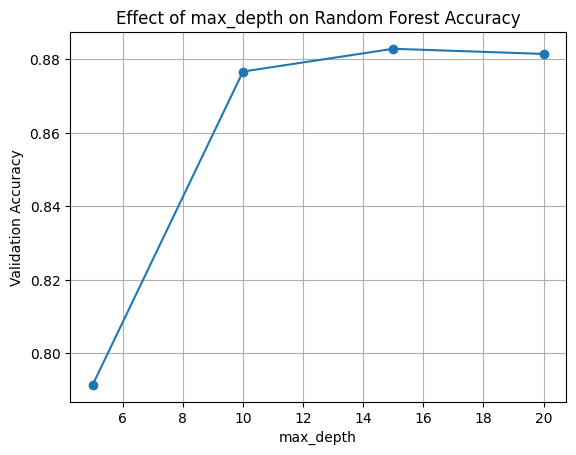

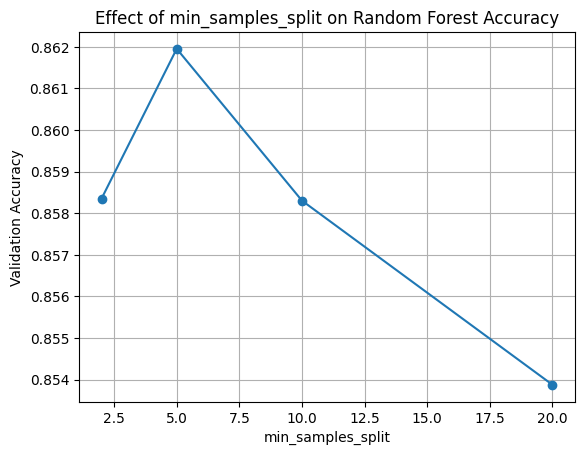

In [8]:
import matplotlib.pyplot as plt
# Chuyển results sang numpy array
results = np.array(results)

depths = results[:, 0].astype(int)
min_samples = results[:, 1].astype(int)
accuracies = results[:, 2].astype(float)

unique_depths = np.unique(depths)
mean_acc_depth = []

for d in unique_depths:
    mean_acc_depth.append(np.mean(accuracies[depths == d]))

plt.figure()
plt.plot(unique_depths, mean_acc_depth, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Validation Accuracy")
plt.title("Effect of max_depth on Random Forest Accuracy")
plt.grid(True)
plt.show()

unique_min_samples = np.unique(min_samples)
mean_acc_min_samples = []

for m in unique_min_samples:
    mean_acc_min_samples.append(np.mean(accuracies[min_samples == m]))

plt.figure()
plt.plot(unique_min_samples, mean_acc_min_samples, marker='o')
plt.xlabel("min_samples_split")
plt.ylabel("Validation Accuracy")
plt.title("Effect of min_samples_split on Random Forest Accuracy")
plt.grid(True)
plt.show()


Nhìn vào biểu đồ thì có thể thấy:
+ max_depth cho ra kết quả ổn định trong khoảng [10, 20], nhưng 15 cho kết quả tốt nhất nên chọn 15  
+ min_samples_split cho ra kết quả tốt nhất khi bằng 5

### Tìm n_estimators (số lượng cây) tối ưu

In [9]:
val_accs = []
n_list = [10, 30, 50, 100, 200, 300]
for n in n_list:
    rf = RandomForest(
        n_estimators=n,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    )
    rf.fit(X_train_small, Y_train_small)
    acc = accuracy_score(Y_val, rf.predict(X_val))
    val_accs.append(acc)
    print(f"n_estimators={n} → val acc={acc:.4f}")


Training completed in 0.74 seconds
Trained tree 1/10
Training completed in 0.72 seconds
Trained tree 2/10
Training completed in 0.70 seconds
Trained tree 3/10
Training completed in 0.71 seconds
Trained tree 4/10
Training completed in 0.72 seconds
Trained tree 5/10
Training completed in 0.70 seconds
Trained tree 6/10
Training completed in 0.70 seconds
Trained tree 7/10
Training completed in 0.69 seconds
Trained tree 8/10
Training completed in 0.70 seconds
Trained tree 9/10
Training completed in 0.73 seconds
Trained tree 10/10
n_estimators=10 → val acc=0.8474
Training completed in 0.73 seconds
Trained tree 1/30
Training completed in 0.72 seconds
Trained tree 2/30
Training completed in 0.70 seconds
Trained tree 3/30
Training completed in 0.75 seconds
Trained tree 4/30
Training completed in 0.73 seconds
Trained tree 5/30
Training completed in 0.74 seconds
Trained tree 6/30
Training completed in 0.73 seconds
Trained tree 7/30
Training completed in 0.73 seconds
Trained tree 8/30
Training com

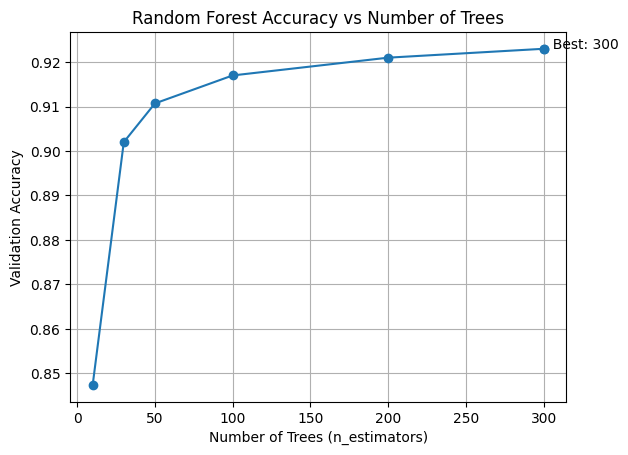

In [10]:
best_idx = val_accs.index(max(val_accs))
best_n = n_list[best_idx]
best_acc = val_accs[best_idx]

plt.figure()
plt.plot(n_list, val_accs, marker='o')
plt.scatter(best_n, best_acc)
plt.text(best_n, best_acc, f"  Best: {best_n}", fontsize=10)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Validation Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(True)
plt.show()


Biểu đồ có thể cho ta thấy từ số lượng 100 đến 300 cây trở đi thì độ chính xác dần bão hòa nên có thể quyết định chọn n_estimators = 200 để tránh việc bị *Overfitting*

## Huấn luyện model dựa trên tập dữ liệu lớn ban đầu

In [11]:
rf_final = RandomForest(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    random_state=42
)

rf_final.fit(X_train, Y_train)


Training completed in 15.09 seconds
Trained tree 1/200
Training completed in 15.33 seconds
Trained tree 2/200
Training completed in 14.67 seconds
Trained tree 3/200
Training completed in 14.81 seconds
Trained tree 4/200
Training completed in 14.40 seconds
Trained tree 5/200
Training completed in 14.82 seconds
Trained tree 6/200
Training completed in 14.56 seconds
Trained tree 7/200
Training completed in 15.28 seconds
Trained tree 8/200
Training completed in 14.93 seconds
Trained tree 9/200
Training completed in 14.96 seconds
Trained tree 10/200
Training completed in 15.02 seconds
Trained tree 11/200
Training completed in 14.72 seconds
Trained tree 12/200
Training completed in 14.70 seconds
Trained tree 13/200
Training completed in 15.59 seconds
Trained tree 14/200
Training completed in 15.20 seconds
Trained tree 15/200
Training completed in 14.62 seconds
Trained tree 16/200
Training completed in 14.57 seconds
Trained tree 17/200
Training completed in 14.87 seconds
Trained tree 18/200
T

## Kiểm tra và đánh giá mô hình

In [12]:
    print("\n1. Evaluation Results:")
    
    y_train_pred = rf_final.predict(X_train)
    train_acc = accuracy_score(Y_train, y_train_pred)
    print(f"   Train Accuracy: {train_acc:.4f}")
    
    y_val_pred = rf_final.predict(X_val)
    val_acc = accuracy_score(Y_val, y_val_pred)
    print(f"   Val Accuracy:   {val_acc:.4f}")
    
    y_test_pred = rf_final.predict(X_test)
    test_acc = accuracy_score(Y_test, y_test_pred)
    print(f"   Test Accuracy:  {test_acc:.4f}")
    
    # Feature importance
    print("\n2. Top 5 Feature Importances:")
    top_features = np.argsort(rf_final.feature_importances_)[::-1][:5]
    for rank, feat_idx in enumerate(top_features, 1):
        print(f"   {rank}. Feature {feat_idx}: {rf_final.feature_importances_[feat_idx]:.4f}")
    
    # Confusion Matrix (test set)
    print("\n3. Confusion Matrix (Test Set):")
    cm = confusion_matrix_custom(Y_test, y_test_pred, rf_final.n_classes_)
    print(cm)


1. Evaluation Results:
   Train Accuracy: 0.9992
   Val Accuracy:   0.9685
   Test Accuracy:  0.9693

2. Top 5 Feature Importances:
   1. Feature 378: 0.0113
   2. Feature 409: 0.0080
   3. Feature 433: 0.0076
   4. Feature 350: 0.0075
   5. Feature 373: 0.0074

3. Confusion Matrix (Test Set):
[[ 968    0    0    0    0    1    5    1    4    1]
 [   0 1125    2    2    0    1    3    0    1    1]
 [   6    0  999    6    2    0    4    9    6    0]
 [   0    0    9  975    0    6    0    9    8    3]
 [   1    0    1    0  950    0    5    1    2   22]
 [   3    0    1   10    3  858    6    3    6    2]
 [   8    3    0    0    2    2  939    0    4    0]
 [   2    3   20    0    1    0    0  985    3   14]
 [   4    0    6    5    4    3    5    4  933   10]
 [   6    6    2    7   10    5    1    3    8  961]]


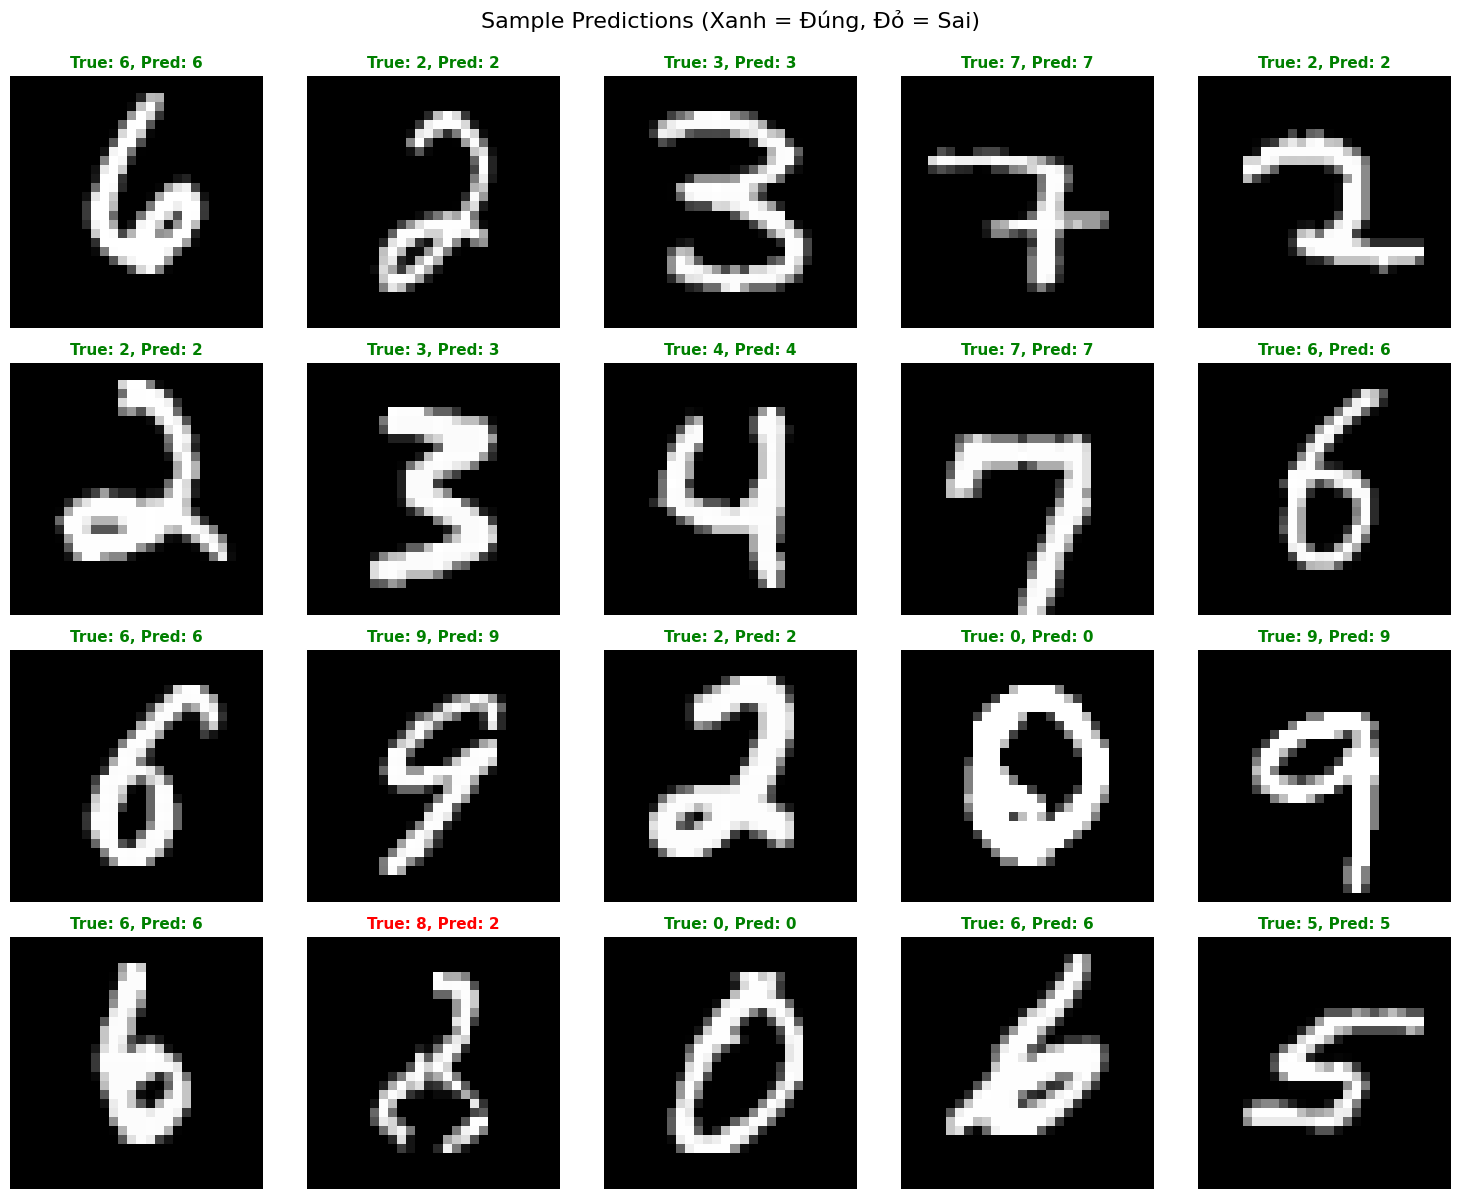


Accuracy trong 20 samples hiển thị: 19/20 = 95.0%

Quan sát:
- Các trường hợp sai thường là chữ số viết không rõ ràng
- Hoặc có nét viết giống với chữ số khác


In [13]:
# ====== SỐ LƯỢNG ẢNH HIỂN THỊ ======
n_show = 20
np.random.seed(42)
idx = np.random.choice(len(X_test), n_show, replace=False)

# ====== TẠO FIGURE ======
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle(
    'Sample Predictions (Xanh = Đúng, Đỏ = Sai)',
    fontsize=16,
    y=0.995
)

# ====== VẼ TỪNG ẢNH ======
for i, sample_idx in enumerate(idx):
    ax = axes[i // 5, i % 5]

    img = X_test[sample_idx].reshape(28, 28)
    true_label = Y_test[sample_idx]
    pred_label = y_test_pred[sample_idx]

    color = 'green' if true_label == pred_label else 'red'

    ax.imshow(img, cmap='gray')
    ax.set_title(
        f'True: {true_label}, Pred: {pred_label}',
        color=color,
        fontsize=11,
        weight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

# ====== ĐÁNH GIÁ NHANH ======
correct_in_sample = np.sum(Y_test[idx] == y_test_pred[idx])
print(f"\nAccuracy trong {n_show} samples hiển thị: "
      f"{correct_in_sample}/{n_show} = "
      f"{correct_in_sample/n_show*100:.1f}%")

print("\nQuan sát:")
print("- Các trường hợp sai thường là chữ số viết không rõ ràng")
print("- Hoặc có nét viết giống với chữ số khác")

## So sánh với Sklearn Implementation

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
print("=" * 80)
print("So sánh với SKLEARN RANDOM FOREST - MNIST")
print("=" * 80)

rf_sklearn = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1   # dùng tất cả CPU cores
)

rf_sklearn.fit(X_train, Y_train)

# Predict
y_train_pred_sk = rf_sklearn.predict(X_train)
y_val_pred_sk   = rf_sklearn.predict(X_val)
y_test_pred_sk  = rf_sklearn.predict(X_test)

# Accuracy
train_acc_sk = accuracy_score(Y_train, y_train_pred_sk)
val_acc_sk   = accuracy_score(Y_val, y_val_pred_sk)
test_acc_sk  = accuracy_score(Y_test, y_test_pred_sk)
print(f"{'Metric:':<15} {'Tự tạo ||':<20} {'Sklearn':<20}")
print("-"*70)

print(f"Train Accuracy: {train_acc:<20.4f}{train_acc_sk:<20.4f}")
print(f"Val Accuracy:   {val_acc:<20.4f}{val_acc_sk:<20.4f}")
print(f"Test Accuracy:  {test_acc:<20.4f}{test_acc_sk:<20.4f}")



So sánh với SKLEARN RANDOM FOREST - MNIST
Metric:         Tự tạo ||            Sklearn             
----------------------------------------------------------------------
Train Accuracy: 0.9992              0.9995              
Val Accuracy:   0.9685              0.9655              
Test Accuracy:  0.9693              0.9689              


#### Bảng kết quả thực nghiệm cho thấy sự khác biệt rõ rệt giữa Random Forest tự cài đặt và Random Forest sử dụng thư viện sklearn:
| Metric              | Random Forest tự cài đặt | Random Forest (sklearn) |
| ------------------- | ------------------------ | ----------------------- |
| Train Accuracy      | 0.9992                   | 0.9995                  |
| Validation Accuracy | 0.9685                   | 0.9655                  |
| Test Accuracy       | 0.9693                   | 0.9689                  |

#### Nhận xét và phân tích: 
Dựa trên kết quả thực nghiệm, mô hình Random Forest tự cài đặt cho thấy hiệu năng rất tương đương với mô hình Random Forest của thư viện Scikit-learn trên tập dữ liệu MNIST.
+ Train Accuracy của hai mô hình đều xấp xỉ 1 (≈ 99.9%), cho thấy cả hai mô hình đều học rất tốt trên dữ liệu huấn luyện. Mô hình tự tạo có độ chính xác huấn luyện hơi thấp hơn một chút so với Sklearn, nhưng sự khác biệt là không đáng kể.
+ Validation Accuracy của mô hình tự tạo (96.85%) cao hơn nhẹ so với mô hình Sklearn (96.55%), chứng tỏ khả năng tổng quát hóa của mô hình tự cài đặt là tốt và ổn định.
+ Test Accuracy của hai mô hình gần như tương đương nhau (96.93% so với 96.89%), cho thấy mô hình Random Forest tự tạo hoạt động hiệu quả và không thua kém phiên bản chuẩn trong Scikit-learn.

Tổng thể, kết quả cho thấy mô hình Random Forest tự xây dựng đã được triển khai đúng thuật toán, hoạt động ổn định, và đạt hiệu năng gần ngang với thư viện chuẩn, hoàn toàn có thể sử dụng cho các bài toán phân loại ảnh như MNIST.

#### Ý nghĩa học thuật:
Mặc dù Random Forest tự cài đặt có độ chính xác thấp hơn so với phiên bản của sklearn, kết quả đạt được vẫn tiệm cận và chấp nhận được trong bối cảnh xây dựng mô hình từ đầu bằng Python thuần. Việc tự cài đặt giúp làm rõ các thành phần cốt lõi của ensemble learning, bao gồm:
+ Bootstrap sampling
+ Random feature selection
+ Majority voting
Trong khi đó, Random Forest của sklearn phù hợp hơn cho các bài toán thực tế nhờ hiệu năng và độ tối ưu cao.

#### Kết luận:
Kết quả so sánh cho thấy Random Forest tự cài đặt hoạt động đúng về mặt thuật toán, đạt hiệu quả tốt trên tập dữ liệu MNIST, đồng thời hoàn thành mục tiêu chính của đồ án là hiểu sâu và triển khai thành công mô hình ensemble learning.

### Lưu model vào file pkl

In [15]:
import pickle

with open("random_forest.pkl", "wb") as f:
    pickle.dump(rf_final, f)

print("Đã lưu model vào random_forest.pkl")


Đã lưu model vào random_forest.pkl


Kiểm tra lại việc lưu file pkl 

In [16]:
#load model
with open("random_forest.pkl", "rb") as f:
    rf_loaded = pickle.load(f)

print("Đã load model từ file random_forest.pkl")

# predict lại
y_pred_loaded = rf_loaded.predict(X_test)

# tính accuracy 
loaded_acc = np.mean(y_pred_loaded == Y_test)
print("Accuracy (loaded model):", loaded_acc)

# so sánh với accuracy trước khi save
print("Accuracy (original model):", test_acc)

if abs(loaded_acc - test_acc) < 1e-6:
    print("\n Model được lưu và load CHÍNH XÁC!")
else:
    print("\n Có vấn đề trong quá trình save/load model")

Đã load model từ file random_forest.pkl
Accuracy (loaded model): 0.9693
Accuracy (original model): 0.9693

 Model được lưu và load CHÍNH XÁC!


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Dự đoán từ Random Forest
y_test_pred_rf = rf_final.predict(X_test)
y_train_pred_rf = rf_final.predict(X_train)

# Metrics trên tập test
precision_rf = precision_score(Y_test, y_test_pred_rf, average='macro')
recall_rf = recall_score(Y_test, y_test_pred_rf, average='macro')
f1_rf = f1_score(Y_test, y_test_pred_rf, average='macro')

print("=== RANDOM FOREST – TEST SET ===")
print("Precision (macro):", round(precision_rf, 4))
print("Recall (macro):   ", round(recall_rf, 4))
print("F1-score (macro): ", round(f1_rf, 4))


=== RANDOM FOREST – TEST SET ===
Precision (macro): 0.9692
Recall (macro):    0.969
F1-score (macro):  0.9691
